In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib


In [ ]:
df = pd.read_csv("Internship_Eligibility_Predictor.csv")

print(df.head())
print(df.shape)


   Student_ID  CGPA  Technical_Skills_Count  Soft_Skills_Count  \
0           1  6.87                       1                  2   
1           2  9.75                       1                  5   
2           3  8.66                       7                  4   
3           4  7.99                       0                  0   
4           5  5.78                       6                  1   

   Projects_Count  Certifications_Count  Internship_Experience  \
0               2                     0                      1   
1               5                     0                      0   
2               0                     1                      0   
3               3                     4                      1   
4               5                     4                      1   

   Workshops_Attended  Hackathons_Participated  Eligible  
0                   1                        0         0  
1                   5                        1         0  
2                   3        

In [ ]:
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               25000 non-null  int64  
 1   CGPA                     25000 non-null  float64
 2   Technical_Skills_Count   25000 non-null  int64  
 3   Soft_Skills_Count        25000 non-null  int64  
 4   Projects_Count           25000 non-null  int64  
 5   Certifications_Count     25000 non-null  int64  
 6   Internship_Experience    25000 non-null  int64  
 7   Workshops_Attended       25000 non-null  int64  
 8   Hackathons_Participated  25000 non-null  int64  
 9   Eligible                 25000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 1.9 MB


,Student_ID,CGPA,Technical_Skills_Count,Soft_Skills_Count,Projects_Count,Certifications_Count,Internship_Experience,Workshops_Attended,Hackathons_Participated,Eligible
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,7.506168,3.511240,2.502760,2.49324,2.010560,0.495680,2.489520,1.992400,0.252640
std,7217.022701,1.442833,2.279842,1.713018,1.70840,1.417085,0.499991,1.704349,1.412523,0.434535
min,1.000000,5.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6250.750000,6.260000,2.000000,1.000000,1.00000,1.000000,0.000000,1.000000,1.000000,0.000000
50%,12500.500000,7.510000,4.000000,3.000000,2.00000,2.000000,0.000000,2.000000,2.000000,0.000000
75%,18750.250000,8.750000,5.250000,4.000000,4.00000,3.000000,1.000000,4.000000,3.000000,1.000000
max,25000.000000,10.000000,7.000000,5.000000,5.00000,4.000000,1.000000,5.000000,4.000000,1.000000


In [ ]:
df.isnull().sum()


Student_ID                 0
CGPA                       0
Technical_Skills_Count     0
Soft_Skills_Count          0
Projects_Count             0
Certifications_Count       0
Internship_Experience      0
Workshops_Attended         0
Hackathons_Participated    0
Eligible                   0
dtype: int64

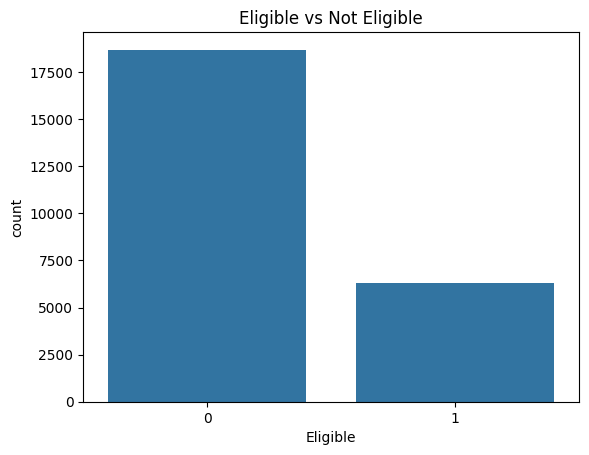

In [ ]:
sns.countplot(x='Eligible', data=df)
plt.title("Eligible vs Not Eligible")
plt.show()


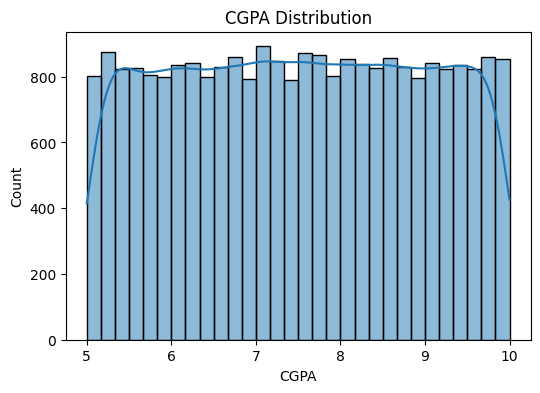

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['CGPA'], kde=True)
plt.title("CGPA Distribution")
plt.show()


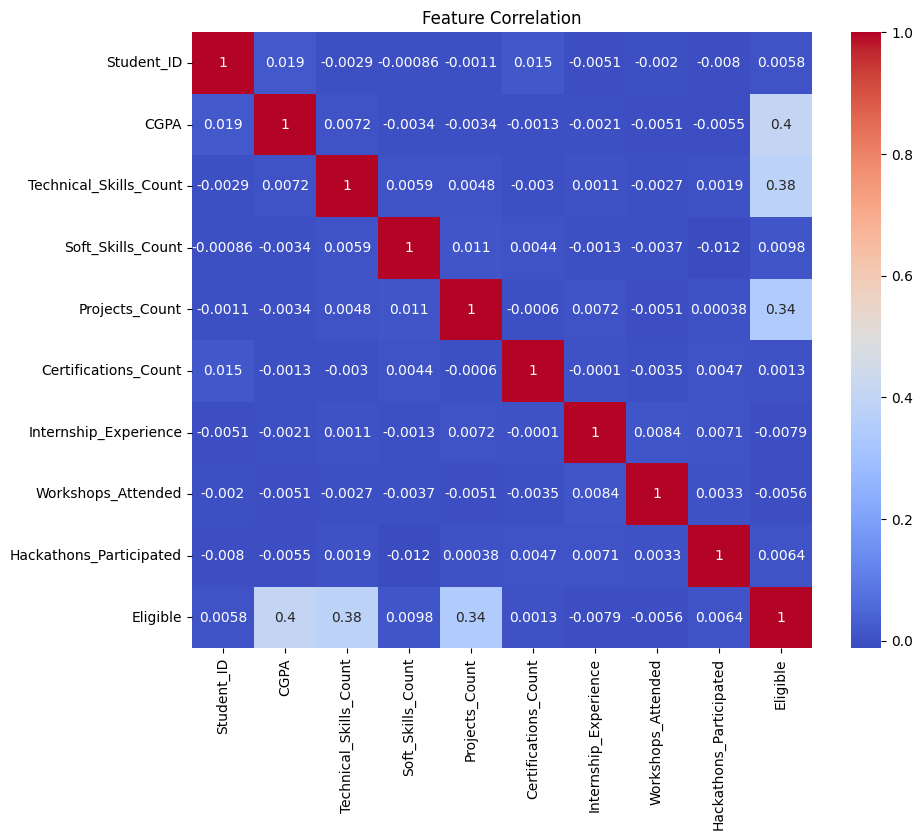

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


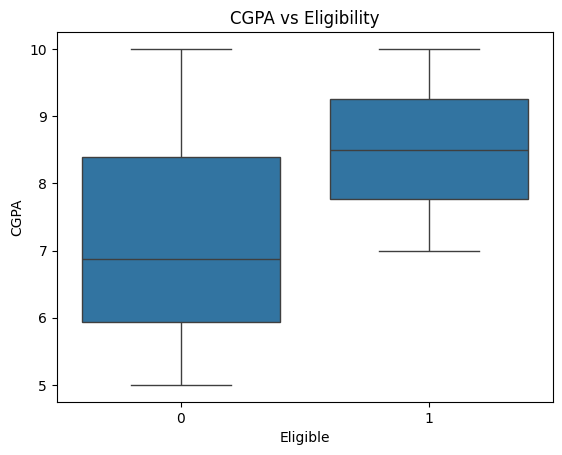

In [ ]:
sns.boxplot(x='Eligible', y='CGPA', data=df)
plt.title("CGPA vs Eligibility")
plt.show()


In [ ]:
X = df.drop(['Student_ID', 'Eligible'], axis=1)
y = df['Eligible']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.8718


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 1.0


In [ ]:
print("Classification Report:\n",
      classification_report(y_test, y_pred_rf))

print("Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred_rf))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3728
           1       1.00      1.00      1.00      1272

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000

Confusion Matrix:
 [[3728    0]
 [   0 1272]]


In [ ]:
joblib.dump(rf, "internship_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']